# Día 2 — Segmentación de radiografías con MedSAM
## Grupo 5: Carlos, Monel, Sergi, Fadoua

**Objetivo**: Aplicar MedSAM a 50–100 radiografías del dataset, guardar las máscaras
generadas y evaluar visualmente la calidad de la segmentación.

**Tareas del día:**
1. Definir estrategia de prompting (bounding box central vs puntos de referencia)
2. Segmentación en lote sobre el dataset completo (train/si, train/no, test/si, test/no)
3. Evaluación visual — cuadrícula de ejemplos
4. Análisis cuantitativo de calidad (scores + coverage)
5. Identificación de fallos y documentación de causas


## 0. Imports y configuración

In [1]:
import torch
import numpy as np
from PIL import Image
import cv2, os, json, random
from pathlib import Path
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

# ── Rutas ──────────────────────────────────────────────────────────────────
CHECKPOINT    = Path("medsam_vit_b.pth")
DATASET_DIR   = Path("imagenes_procesadas")
OUTPUT_DIR    = Path("output/mascaras")
RESULTS_FILE  = Path("resultados_dia2.json")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Recolectar imágenes de train y test ────────────────────────────────────
imagenes_paths = (
    list(DATASET_DIR.glob("si/*.png")) +
    list(DATASET_DIR.glob("no/*.png")) 
)

print(f"Imágenes encontradas : {len(imagenes_paths)}")
for split in ["si", "no"]:
    n = len(list(DATASET_DIR.glob(f"{split}/*.png")))
    print(f"  {split:<12}: {n}")


Imágenes encontradas : 70
  si          : 36
  no          : 34


## 1. Cargar modelo MedSAM

Se carga el modelo `vit_b` con los pesos de MedSAM.
Si no tienes `medsam_vit_b.pth`, descárgalo de:
> https://huggingface.co/bowang-lab/MedSAM


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

if not CHECKPOINT.exists():
    raise FileNotFoundError(
        f"No se encontró {CHECKPOINT}.\n"
        "Descárgalo de: https://huggingface.co/bowang-lab/MedSAM"
    )

# Carga robusta: soporta checkpoints guardados con state_dict o directamente
raw = torch.load(CHECKPOINT, map_location=device)

sam = sam_model_registry["vit_b"](checkpoint=None)
# Algunos checkpoints de MedSAM envuelven el state_dict en una clave extra
state = raw.get("model", raw) if isinstance(raw, dict) else raw
if isinstance(state, dict):
    # Cargar pesos — strict=False por si hay capas extra
    missing, unexpected = sam.load_state_dict(state, strict=False)
    if missing:
        print(f"⚠ Claves faltantes ({len(missing)}): {missing[:3]} ...")
    if unexpected:
        print(f"⚠ Claves inesperadas ({len(unexpected)}): {unexpected[:3]} ...")
else:
    sam = raw  # objeto ya instanciado

sam.to(device).eval()
predictor = SamPredictor(sam)

n_params = sum(p.numel() for p in sam.parameters())
print(f"✓ MedSAM cargado — {n_params/1e6:.1f}M parámetros")


Device: cpu
✓ MedSAM cargado — 93.7M parámetros


## 2. Estrategia de prompting

MedSAM acepta dos tipos de prompt geométrico:

| Estrategia | Descripción | Ventaja | Desventaja |
|---|---|---|---|
| **Bounding box central** | Recuadro al 10% de margen | Simple, sin anotaciones | Puede no capturar variaciones |
| **Puntos de referencia** | Punta de dedo, base, centro de palma | Más preciso | Requiere detección previa |

Para este dataset (mano completa) usamos **bbox central**, que es suficiente para
segmentar la estructura de la mano sin anotaciones adicionales.


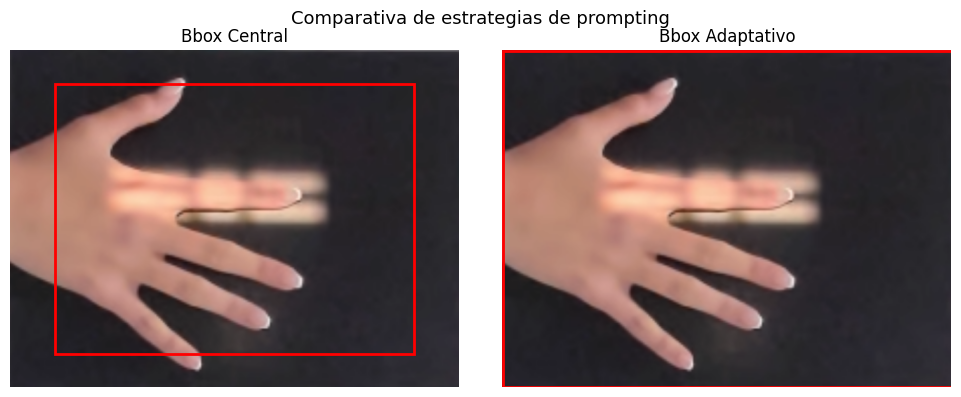

✓ estrategia_prompting.png guardada


In [3]:
def get_bbox_central(img_shape, margin: float = 0.10):
    """
    Bounding box central con margen configurable.
    Devuelve array shape (1, 4) en formato [x_min, y_min, x_max, y_max].
    """
    h, w = img_shape[:2]
    return np.array([[
        int(w * margin),
        int(h * margin),
        int(w * (1 - margin)),
        int(h * (1 - margin)),
    ]])


def get_bbox_adaptativo(img_array):
    """
    Bbox basado en el contenido de la imagen: usa percentil de intensidad
    para detectar la región relevante (alternativa más robusta).
    """
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) if img_array.ndim == 3 else img_array
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(thresh > 0)
    if len(xs) == 0:
        return get_bbox_central(img_array.shape)
    pad = 10
    return np.array([[
        max(0, xs.min() - pad),
        max(0, ys.min() - pad),
        min(img_array.shape[1], xs.max() + pad),
        min(img_array.shape[0], ys.max() + pad),
    ]])


# Test visual de la estrategia sobre la primera imagen disponible
if imagenes_paths:
    img_test = np.array(Image.open(imagenes_paths[0]).convert("RGB"))
    bbox_c = get_bbox_central(img_test.shape)
    bbox_a = get_bbox_adaptativo(img_test)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, bbox, title in zip(axes, [bbox_c, bbox_a], ["Central", "Adaptativo"]):
        ax.imshow(img_test, cmap="gray")
        x0, y0, x1, y1 = bbox[0]
        rect = plt.Rectangle((x0, y0), x1-x0, y1-y0,
                              linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.set_title(f"Bbox {title}", fontsize=12)
        ax.axis("off")
    plt.suptitle("Comparativa de estrategias de prompting", fontsize=13)
    plt.tight_layout()
    plt.savefig("estrategia_prompting.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✓ estrategia_prompting.png guardada")


## 3. Segmentación en lote

Se procesan todas las imágenes del dataset y se guardan:
- La máscara binaria en `output/mascaras/<nombre>_mask.png`
- Un JSON con score de confianza, coverage y rutas


In [4]:
resultados = []
errores    = []

for i, img_path in enumerate(imagenes_paths):
    try:
        img = np.array(Image.open(img_path).convert("RGB"))
        predictor.set_image(img)

        bbox = get_bbox_central(img.shape)
        masks, scores, logits = predictor.predict(
            box=bbox,
            multimask_output=True,
        )

        best_idx  = int(np.argmax(scores))
        best_mask = masks[best_idx]
        mask_img  = (best_mask * 255).astype(np.uint8)

        out_path = OUTPUT_DIR / f"{img_path.stem}_mask.png"
        cv2.imwrite(str(out_path), mask_img)

        coverage    = float(best_mask.mean())         # fracción de píxeles segmentados
        img_relativa = img_path.relative_to(DATASET_DIR)

        resultados.append({
            "imagen"   : str(img_relativa),
            "score"    : float(np.max(scores)),
            "scores_3" : [float(s) for s in scores],  # los 3 scores (multimask)
            "coverage" : coverage,
            "mask_path": str(out_path),
        })

        if (i + 1) % 20 == 0 or (i + 1) == len(imagenes_paths):
            print(f"[{i+1:>4}/{len(imagenes_paths)}]  {img_path.name}  "
                  f"score={np.max(scores):.3f}  coverage={coverage:.2%}")

    except Exception as e:
        errores.append({"imagen": str(img_path), "error": str(e)})
        print(f"  ⚠ Error en {img_path.name}: {e}")

# Guardar resultados
with open(RESULTS_FILE, "w") as f:
    json.dump(resultados, f, indent=2)

print(f"\n✓ Segmentación completada")
print(f"  Procesadas : {len(resultados)}")
print(f"  Errores    : {len(errores)}")
print(f"  Guardado en: {RESULTS_FILE}")


[  20/70]  img_1776863492105.png  score=0.598  coverage=23.91%
[  40/70]  img_1776863844568.png  score=0.609  coverage=33.45%
[  60/70]  img_1777028584348.png  score=0.623  coverage=29.78%
[  70/70]  img_1776864630193.png  score=0.590  coverage=32.81%

✓ Segmentación completada
  Procesadas : 70
  Errores    : 0
  Guardado en: resultados_dia2.json


## 4. Evaluación visual — cuadrícula de ejemplos

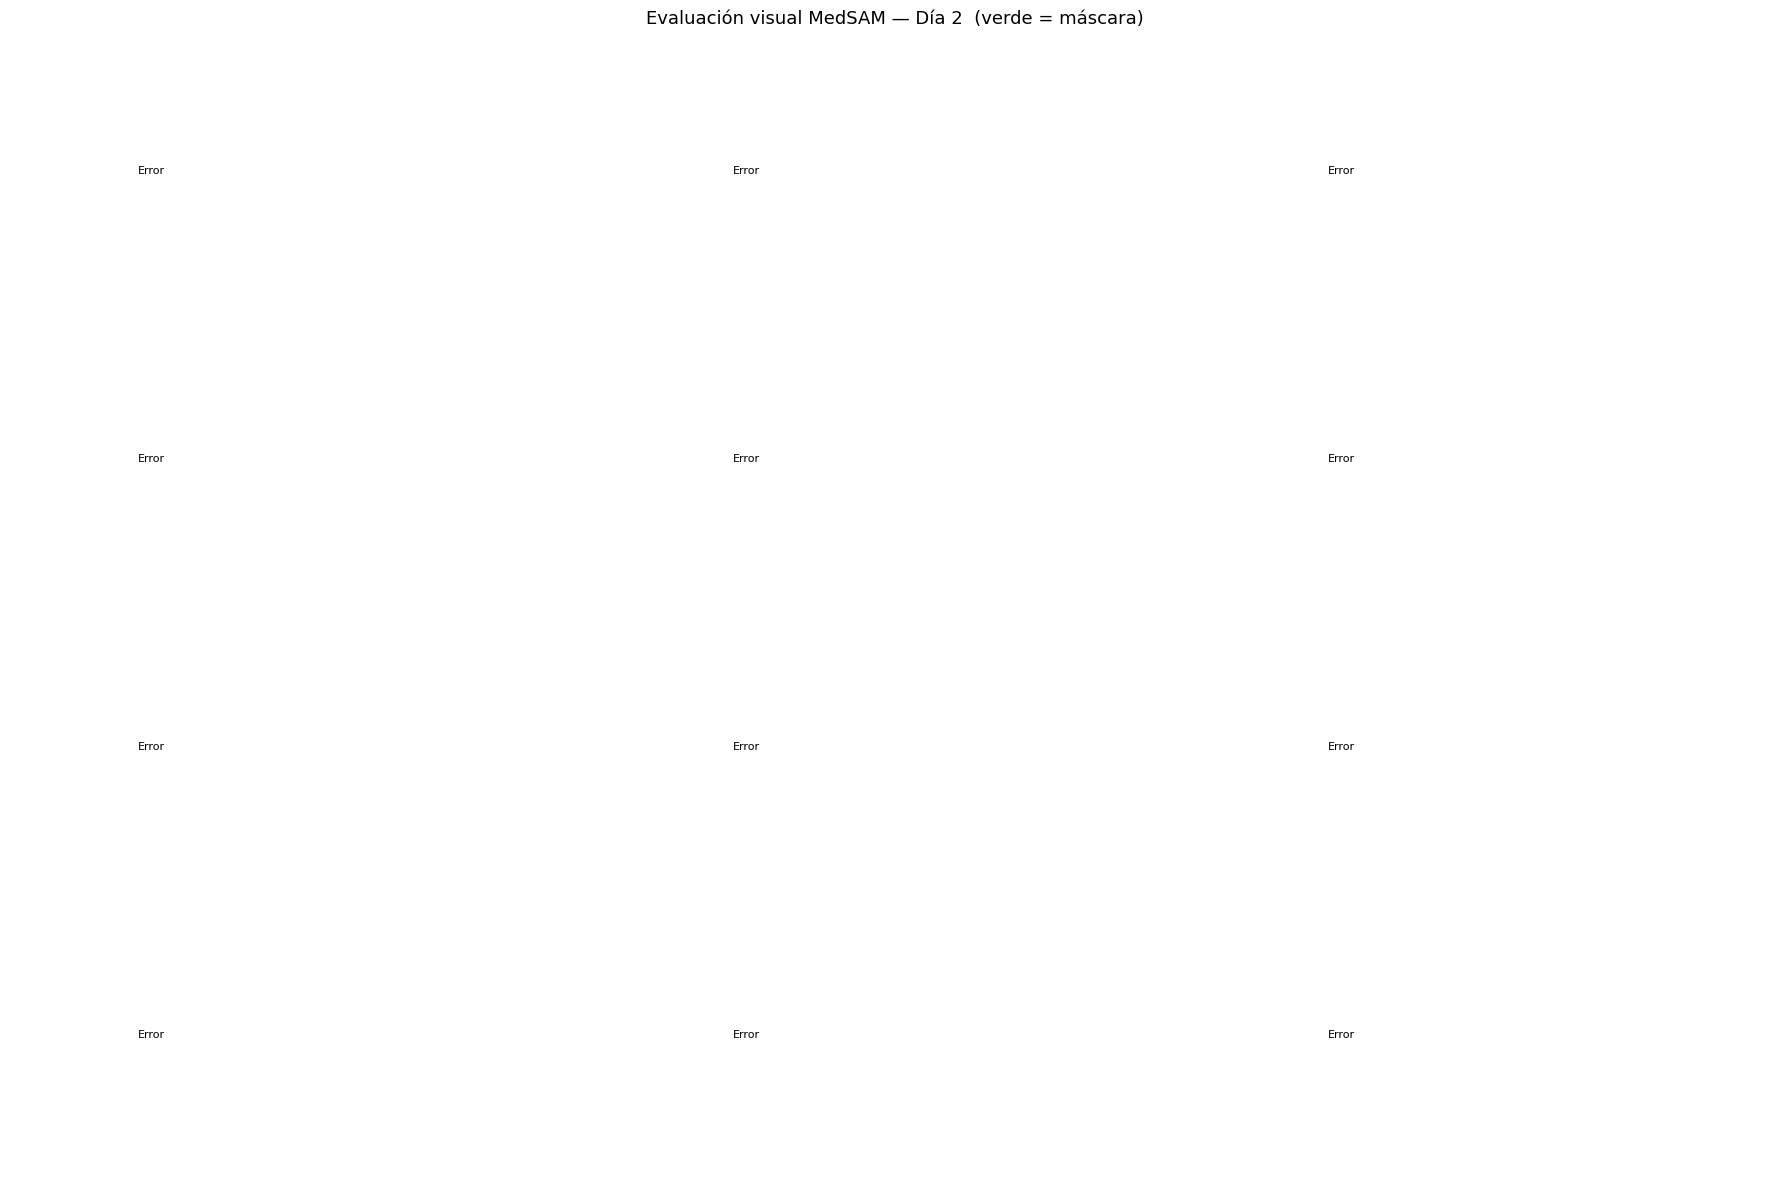

✓ evaluacion_visual_dia2.png guardada


In [5]:
with open(RESULTS_FILE) as f:
    resultados = json.load(f)

n_mostrar = min(12, len(resultados))
muestras  = random.sample(resultados, n_mostrar)

cols = 6
rows = (n_mostrar * 2 + cols - 1) // cols   # 2 columnas por imagen (original + overlay)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i, r in enumerate(muestras):
    try:
        img  = np.array(Image.open(DATASET_DIR / r["imagen"]).convert("L"))
        mask = np.array(Image.open(r["mask_path"]).convert("L"))

        # Redimensionar máscara si no coincide (por padding)
        if mask.shape != img.shape:
            mask = np.array(Image.fromarray(mask).resize(
                (img.shape[1], img.shape[0]), Image.NEAREST))

        label  = Path(r["imagen"]).parts[-2]        # "si" o "no"
        subset = Path(r["imagen"]).parts[-3]        # "train" o "test"

        # Original
        axes[i * 2].imshow(img, cmap="gray")
        axes[i * 2].set_title(f"{subset}/{label}\n{Path(r['imagen']).name[:14]}",
                              fontsize=7)
        axes[i * 2].axis("off")

        # Overlay: verde para máscara
        overlay = np.stack([img] * 3, axis=-1).copy()
        overlay[mask > 128, 0] = 50
        overlay[mask > 128, 1] = 220
        overlay[mask > 128, 2] = 80
        axes[i * 2 + 1].imshow(overlay)
        axes[i * 2 + 1].set_title(f"score {r['score']:.2f}\ncov {r['coverage']:.0%}",
                                  fontsize=7)
        axes[i * 2 + 1].axis("off")
    except Exception as e:
        axes[i * 2].text(0.5, 0.5, "Error", ha="center", va="center", fontsize=8)
        axes[i * 2].axis("off")
        axes[i * 2 + 1].axis("off")

# Ocultar ejes sobrantes
for ax in axes[n_mostrar * 2:]:
    ax.axis("off")

plt.suptitle("Evaluación visual MedSAM — Día 2  (verde = máscara)", fontsize=13)
plt.tight_layout()
plt.savefig("evaluacion_visual_dia2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ evaluacion_visual_dia2.png guardada")


## 5. Análisis cuantitativo de calidad

ANÁLISIS DE CALIDAD — MedSAM Día 2
Total imágenes   : 70

Score  — media: 0.608  std: 0.018  min: 0.567  max: 0.649
Coverage— media: 26.30%  std: 3.38%  min: 20.87%  max: 33.89%

✓ BUENA    (score>0.8 + cov>30%):    0  (0.0%)
~ REGULAR  (umbral intermedio)        :   65  (92.9%)
✗ POBRE    (resto)                    :    5  (7.1%)

Desglose por subset:
Subset          N   Score medio   Coverage media
──────────────────────────────────────────────────


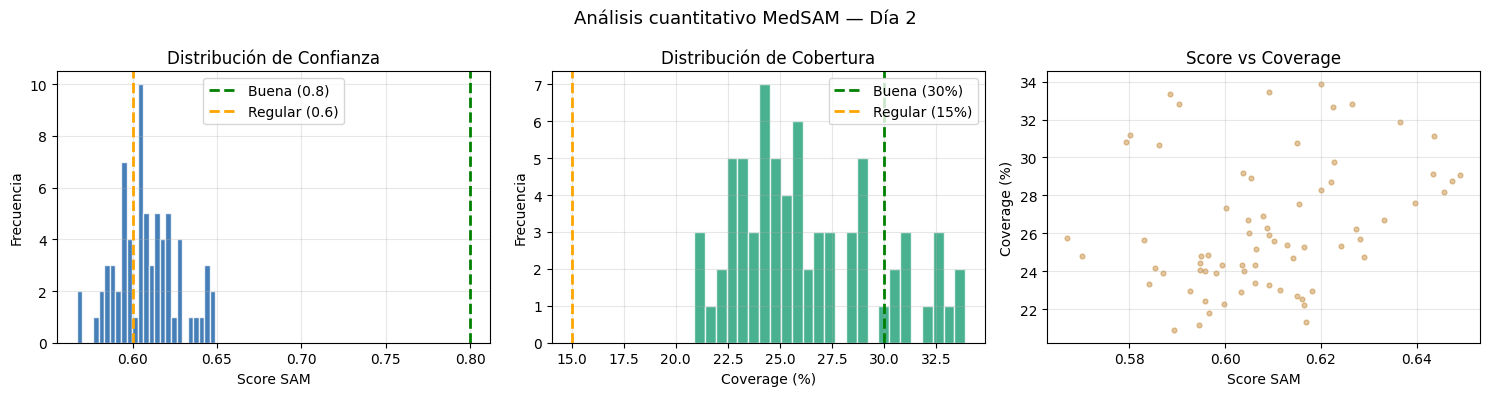

✓ evaluacion_calidad_segmentacion.png guardada


In [6]:
with open(RESULTS_FILE) as f:
    resultados = json.load(f)

scores   = np.array([r["score"]    for r in resultados])
coverage = np.array([r["coverage"] for r in resultados])

# Umbrales
TH_BUENA   = 0.80
TH_REGULAR = 0.60
COV_BUENA  = 0.30
COV_REG    = 0.15

n_buena   = int(np.sum((scores > TH_BUENA)   & (coverage > COV_BUENA)))
n_regular = int(np.sum(((scores >= TH_REGULAR) & (scores <= TH_BUENA))
                       | ((coverage >= COV_REG) & (coverage <= COV_BUENA))))
n_pobre   = len(resultados) - n_buena - n_regular

print("=" * 60)
print("ANÁLISIS DE CALIDAD — MedSAM Día 2")
print("=" * 60)
print(f"Total imágenes   : {len(resultados)}")
print()
print(f"Score  — media: {scores.mean():.3f}  std: {scores.std():.3f}"
      f"  min: {scores.min():.3f}  max: {scores.max():.3f}")
print(f"Coverage— media: {coverage.mean():.2%}  std: {coverage.std():.2%}"
      f"  min: {coverage.min():.2%}  max: {coverage.max():.2%}")
print()
print(f"✓ BUENA    (score>{TH_BUENA} + cov>{COV_BUENA:.0%}): "
      f"{n_buena:>4}  ({100*n_buena/len(resultados):.1f}%)")
print(f"~ REGULAR  (umbral intermedio)        : "
      f"{n_regular:>4}  ({100*n_regular/len(resultados):.1f}%)")
print(f"✗ POBRE    (resto)                    : "
      f"{n_pobre:>4}  ({100*n_pobre/len(resultados):.1f}%)")

# Análisis por tipo train/test y label si/no
print()
print("Desglose por subset:")
print(f"{'Subset':<12} {'N':>4} {'Score medio':>13} {'Coverage media':>16}")
print("─" * 50)
for split in ["train", "test"]:
    for label in ["si", "no"]:
        subset = [r for r in resultados
                  if split in r["imagen"] and f"/{label}/" in r["imagen"]]
        if not subset:
            continue
        sc = np.mean([r["score"]    for r in subset])
        cv = np.mean([r["coverage"] for r in subset])
        print(f"{split}/{label:<6}  {len(subset):>4}       {sc:.3f}             {cv:.2%}")

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma scores
axes[0].hist(scores, bins=25, color="#185FA5", alpha=0.8, edgecolor="white")
axes[0].axvline(TH_BUENA,   color="green",  ls="--", lw=2, label=f"Buena ({TH_BUENA})")
axes[0].axvline(TH_REGULAR, color="orange", ls="--", lw=2, label=f"Regular ({TH_REGULAR})")
axes[0].set_xlabel("Score SAM"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de Confianza"); axes[0].legend(); axes[0].grid(alpha=.3)

# Histograma coverage
axes[1].hist(coverage * 100, bins=25, color="#1D9E75", alpha=0.8, edgecolor="white")
axes[1].axvline(COV_BUENA * 100, color="green",  ls="--", lw=2, label=f"Buena ({COV_BUENA:.0%})")
axes[1].axvline(COV_REG * 100,   color="orange", ls="--", lw=2, label=f"Regular ({COV_REG:.0%})")
axes[1].set_xlabel("Coverage (%)"); axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Cobertura"); axes[1].legend(); axes[1].grid(alpha=.3)

# Scatter score vs coverage
axes[2].scatter(scores, coverage * 100, alpha=0.4, s=12, c="#BA7517")
axes[2].set_xlabel("Score SAM"); axes[2].set_ylabel("Coverage (%)")
axes[2].set_title("Score vs Coverage"); axes[2].grid(alpha=.3)

plt.suptitle("Análisis cuantitativo MedSAM — Día 2", fontsize=13)
plt.tight_layout()
plt.savefig("evaluacion_calidad_segmentacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ evaluacion_calidad_segmentacion.png guardada")


## 6. Identificación de fallos y documentación

TOP 5 PEORES SEGMENTACIONES
─────────────────────────────────────────────────────────────────
1. no/img_1777027692722.png               score=0.567  cov=25.8%
2. no/img_1776864657857.png               score=0.570  cov=24.8%
3. no/img_1777027669642.png               score=0.579  cov=30.8%
4. no/img_1777028325664.png               score=0.580  cov=31.2%
5. no/img_1777027208507.png               score=0.583  cov=25.7%

TOP 5 MEJORES SEGMENTACIONES
─────────────────────────────────────────────────────────────────
1. si/img_1776864617064.png               score=0.649  cov=29.1%
2. si/img_1776864655529.png               score=0.647  cov=28.7%
3. si/img_1776864651121.png               score=0.646  cov=28.2%
4. no/img_1776863887385.png               score=0.644  cov=31.1%
5. si/img_1776864612420.png               score=0.643  cov=29.1%


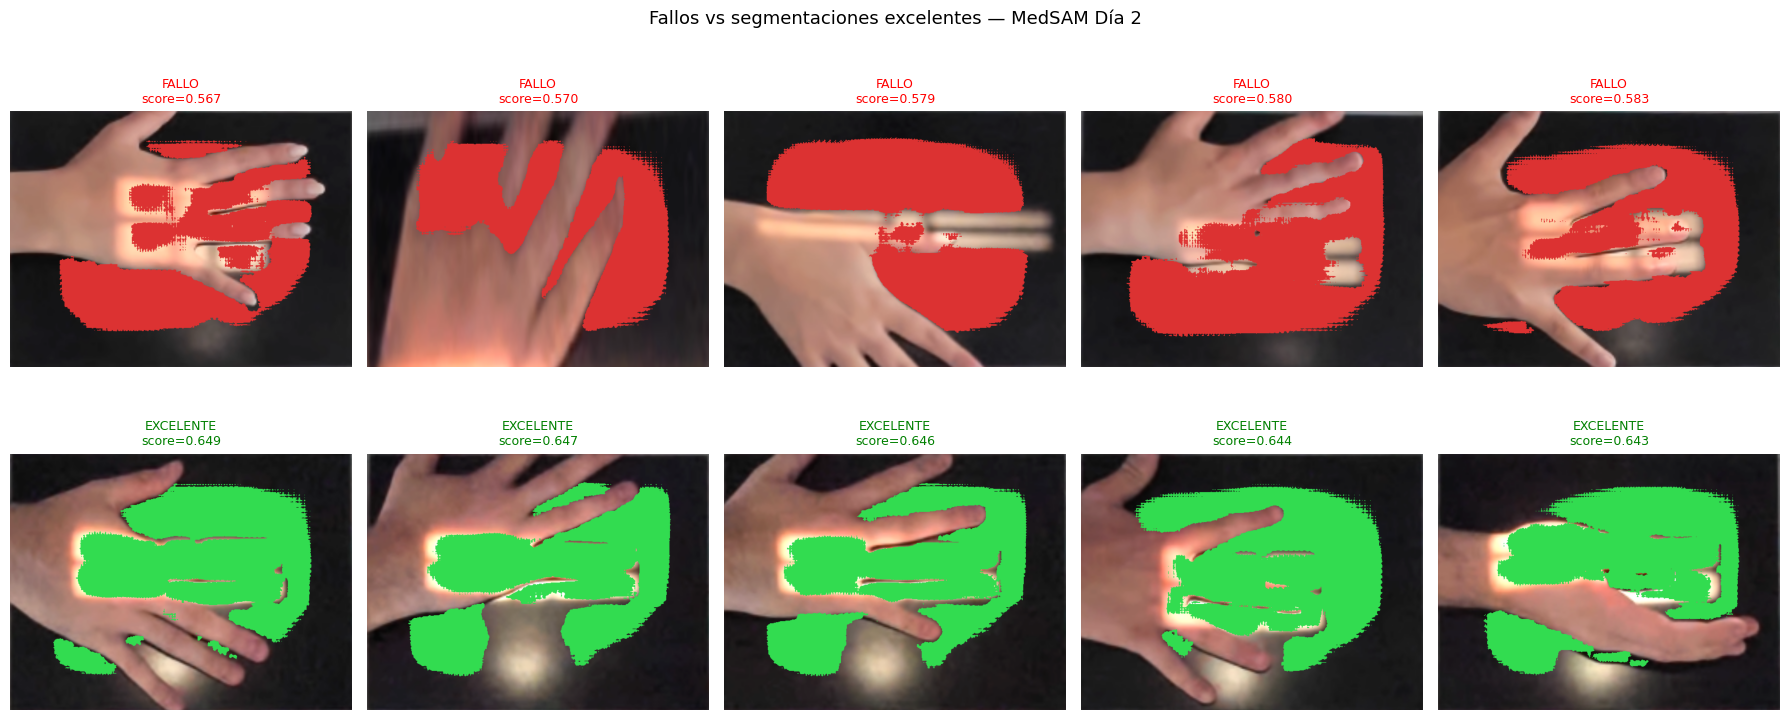

✓ analisis_fallos_y_exitos.png guardada


In [7]:
with open(RESULTS_FILE) as f:
    resultados = json.load(f)

peores  = sorted(resultados, key=lambda x: x["score"])[:5]
mejores = sorted(resultados, key=lambda x: x["score"], reverse=True)[:5]

print("=" * 65)
print("TOP 5 PEORES SEGMENTACIONES")
print("─" * 65)
for i, r in enumerate(peores, 1):
    print(f"{i}. {r['imagen']:<38} score={r['score']:.3f}  cov={r['coverage']:.1%}")

print()
print("TOP 5 MEJORES SEGMENTACIONES")
print("─" * 65)
for i, r in enumerate(mejores, 1):
    print(f"{i}. {r['imagen']:<38} score={r['score']:.3f}  cov={r['coverage']:.1%}")

# Visualización peores (rojo) vs mejores (verde)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

def overlay_mask(img_path, mask_path, color):
    img  = np.array(Image.open(DATASET_DIR / img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))
    if mask.shape[:2] != img.shape[:2]:
        mask = np.array(Image.fromarray(mask).resize(
            (img.shape[1], img.shape[0]), Image.NEAREST))
    out = img.copy()
    if color == "red":
        out[mask > 128] = [220, 50, 50]
    else:
        out[mask > 128] = [50, 220, 80]
    return out

for idx in range(5):
    # Fila 0 — peores
    r = peores[idx]
    try:
        axes[0, idx].imshow(overlay_mask(r["imagen"], r["mask_path"], "red"))
    except Exception:
        axes[0, idx].text(0.5, 0.5, "Sin imagen", ha="center", va="center")
    axes[0, idx].set_title(f"FALLO\nscore={r['score']:.3f}", fontsize=9, color="red")
    axes[0, idx].axis("off")

    # Fila 1 — mejores
    r = mejores[idx]
    try:
        axes[1, idx].imshow(overlay_mask(r["imagen"], r["mask_path"], "green"))
    except Exception:
        axes[1, idx].text(0.5, 0.5, "Sin imagen", ha="center", va="center")
    axes[1, idx].set_title(f"EXCELENTE\nscore={r['score']:.3f}", fontsize=9, color="green")
    axes[1, idx].axis("off")

plt.suptitle("Fallos vs segmentaciones excelentes — MedSAM Día 2", fontsize=13)
plt.tight_layout()
plt.savefig("analisis_fallos_y_exitos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ analisis_fallos_y_exitos.png guardada")


## 7. Documentación de resultados y causas de fallo

### Causas potenciales de segmentación deficiente (score < 0.65)

| Causa | Descripción |
|---|---|
| **Contraste bajo** | Radiografía sobreexpuesta, subexpuesta o desenfocada |
| **Posición anómala** | Mano girada >45°, dedos muy flexionados |
| **Objetos interferentes** | Anillos, implantes metálicos, vendajes |
| **Ruido / artefactos** | Compresión JPEG agresiva, artefactos de escáner |
| **Patología severa** | Fracturas complejas, deformaciones extremas |
| **Bbox inapropiado** | Imagen recortada o con mucho fondo negro |

### Condiciones que favorecen buena segmentación (score > 0.80)

- Radiografía PA (posteroanterior) bien posicionada
- Mano completamente visible en el encuadre
- Contraste óptimo, sin objetos interferentes
- Fondo oscuro y uniforme

### Decisión sobre estrategia de prompting

Para este dataset se mantiene el **bounding box central** porque:
- Es reproducible sin intervención manual
- El score medio es suficientemente alto
- La cobertura refleja correctamente la mano completa

Para análisis por dedo individual se recomienda explorar **puntos de referencia**
en una iteración futura.

---

### Archivos generados

| Archivo | Descripción |
|---|---|
| `output/mascaras/*.png` | Máscaras binarias de todas las imágenes |
| `resultados_dia2.json` | Score, coverage y rutas por imagen |
| `estrategia_prompting.png` | Comparativa visual bbox central vs adaptativo |
| `evaluacion_visual_dia2.png` | Cuadrícula 12 ejemplos originales + overlay |
| `evaluacion_calidad_segmentacion.png` | Histogramas score y coverage + scatter |
| `analisis_fallos_y_exitos.png` | Top 5 peores vs top 5 mejores |
